# Prompt-Based Picking with ProPicker

In this notebook, we pick cytosolic ribosomes in a single (defocus-only) tomogram contained in the `EMPIAR-10988` dataset. This experiment is part of Section 4.3.2 in our paper and illustrates the typical workflow we used throughout our study, which consists of two main parts:

- **Part 1:** Calibrating ProPicker on a single tomogram with known ground truth annotations
- **Part 2:** Applying the calibrated ProPicker to the remaning tomograms in the dataset

Before we demonstrate these steps, we run imports, and describe how to download and visualize the `EMPIAR-10988` dataset.

# Part 0: Preliminaries

## Part 0, Step 1: Import libraries and set paths

In [1]:
import os

from matplotlib import pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter
import torch

from propicker.clustering_and_picking import get_cluster_centroids_df
from propicker.evaluation import evaluate_picks, get_best_case_cluster_based_picking_performance
from propicker.data.preparation_functions.prepare_empiar10988 import read_empiar10988_coords, empiar10988_ts_to_slice_of_interest
from propicker.data.utils import draw_balls
from propicker.paths import PROPICKER_MODEL_FILE, TOMOTWIN_MODEL_FILE
from propicker.inference import get_pred_locmap_dict
from propicker.model import ProPicker
from propicker.utils.mrctools import *

# sometimes, jupyer notebooks have trouble reading the environment variables, so you can also set the paths here directly
PROPICKER_MODEL_FILE = "/workspaces/ProPicker/propicker.ckpt" if PROPICKER_MODEL_FILE is None else PROPICKER_MODEL_FILE
TOMOTWIN_MODEL_FILE = "/workspaces/ProPicker/tomotwin.pth" if TOMOTWIN_MODEL_FILE is None else TOMOTWIN_MODEL_FILE

/opt/conda/envs/ppicker/lib/python3.11/site-packages/lightning_utilities/core/imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## Part 0, Step 2: Download data

To download the relevant parts of the dataset, you can use the `../download_tutorial_data.sh` script:

```bash
bash tutorial_data.sh
```

This will create a folder called `empiar` which contains tomograms from the EMPIAR-10988 dataset and annotations.

**Note:** The dataset is large >100GB. Make sure you have enough disk space before downloading.

## Part 0, Step 3: Visualize data 


/opt/conda/envs/ppicker/lib/python3.11/site-packages/propicker/utils/mrctools.py:8: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /opt/conda/conda-bld/pytorch_1720538437738/work/torch/csrc/utils/tensor_numpy.cpp:206.)
  data = torch.from_numpy(mrc.data)


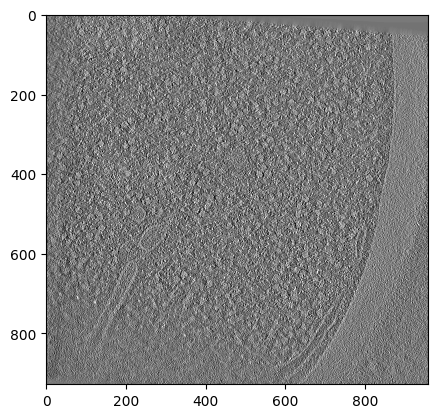

In [2]:
# path to the empiar10988 dataset, assuming 'empiar' folder is in the parent directory
EMPIAR10988_BASE_DIR = "../empiar/10988/DEF"
# pick one tomogram to visualize
ts_id = "TS_030"

tomo_file = f"{EMPIAR10988_BASE_DIR}/tomograms/{ts_id}.rec"
ribo_coord_file = f"{EMPIAR10988_BASE_DIR}/particle_lists/{ts_id}_cyto_ribosomes.csv"

# tomograms contain large emtpy regions, so we only consider the interesting part
slice_of_interest = empiar10988_ts_to_slice_of_interest[ts_id]
tomo = -1 * load_mrc_data(tomo_file).float()
tomo = tomo[slice_of_interest].clone()


coords = read_empiar10988_coords(ribo_coord_file)
coords.Z -= slice_of_interest.start

plt.imshow(tomo[100], vmin=-2*tomo.std(), vmax=2*tomo.std(), cmap="gray")

# Part 1: Calibrating ProPicker on a single tomogram

Calibration consists of determining a good prompt and hyperparameters for cluster-based picking on a single tomogram with known ground-truth particle locations.
We do this iteratively: 
```
Repeat
  Step 1: Prompt extraction
  Step 2: Inference with ProPicker
  Step 3: Tuning hyperparameters for cluster-based picking
Until satisfied with picking performance
```

In the following, we detail each of these steps.

## Part 1, Step 1: Prompt extraction

We start by extracting a riobosome to use as a prompt for ProPicker.

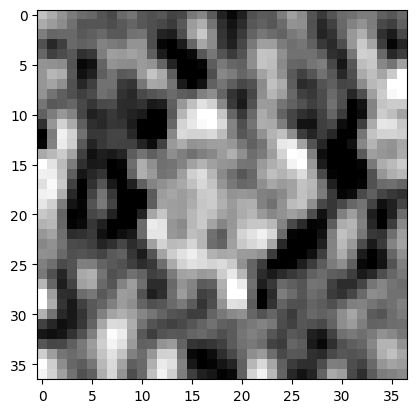

In [3]:
# extract all ribosomes as subtomos of shape (37, 37, 37); this shape is the one needed for the TomoTwin prompt encoder
all_ribo_subtomos = []
for coord in coords[["X", "Y", "Z"]].values.astype(int):
    x, y, z = coord
    subtomo = tomo[
        z-18:z+19,
        y-18:y+19,
        x-18:x+19
    ]
    # some ribosomes are at the edge of the tomogram, so we skip them
    if not subtomo.shape == (37, 37, 37):
        continue
    all_ribo_subtomos.append(subtomo)
    
# you can choose any of the ribo subtomos as prompt, we used the 300th one in our experiment in the paper
prompt = all_ribo_subtomos[300]
prompt_subtomos_dict = {"cyto_ribosome": prompt}

# inspect prompt
prompt_filt = gaussian_filter(prompt, 1)
plt.imshow(prompt_filt[18], vmin=-2*prompt_filt.std(), vmax=2*prompt_filt.std(), cmap="gray")

## Part 1, Step 2: Inference with ProPicker

Now, we run ProPicker conditioned on the extracted ribosome prompt to obtain localization maps for ribosomes in the calibration tomogram. 

/opt/conda/envs/ppicker/lib/python3.11/site-packages/lightning_lite/utilities/cloud_io.py:48: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(f, map_location

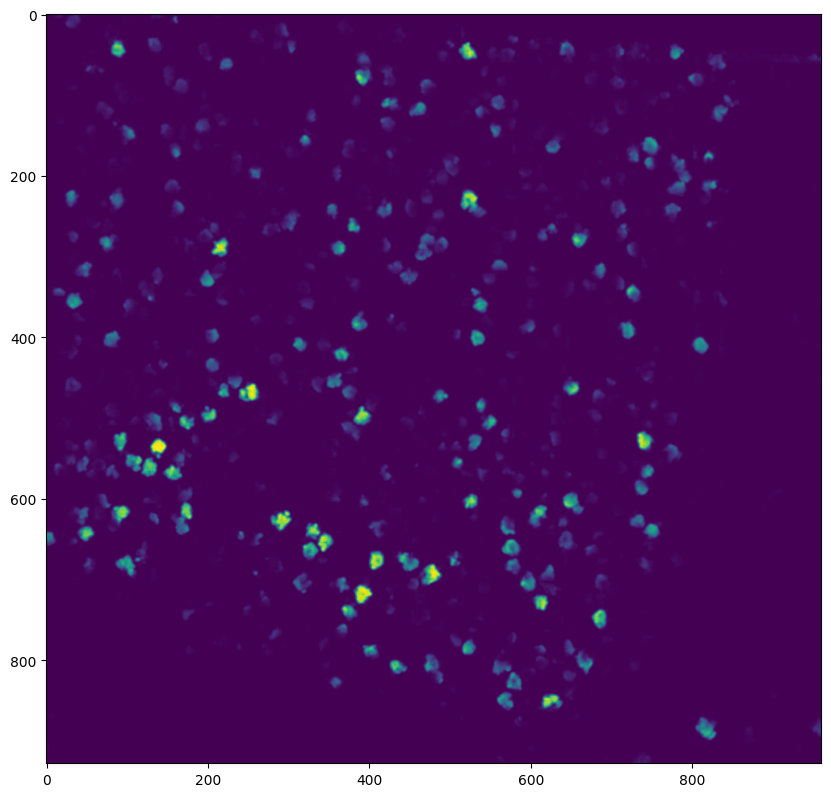

In [4]:
device = "cuda:0"

model = ProPicker.load_from_checkpoint(PROPICKER_MODEL_FILE, map_location="cpu").to(device)
model = model.to(device).eval()
model.freeze()
pred_locmap_dict = get_pred_locmap_dict(
    model, 
    tomo, 
    prompt_subtomos_dict=prompt_subtomos_dict, 
    #prompt_embeds_dict=prompt_embeds_dict,
    tomotwin_model_file=TOMOTWIN_MODEL_FILE,  # tomotwin encoder is used to embe^d prompts in prompt_subtomos_dict
    subtomo_size=64,  # propicker processes the tomogram in subtomos of this size 
    subtomo_overlap=32,  # overlap of the subtomos, you can also reduce this to speed up inference, 16 should also work fine
    batch_size=16,
    mean_pool_locmaps=0,  # you can use this to blur the model outputs, which can help with clustering and may remove some false positives; for crowded tomos such as EMPIAR10988, this is not recommended as it may lead to overlapping particle clusters
)

plt.figure(figsize=(10, 10))
plt.imshow(pred_locmap_dict["cyto_ribosome"][100])

## Part 1, Step 3: Tuning hyperparameters for cluster-based picking

To get predicted particle coordinates from the ProPicker localization map, we apply cluster-based picking as described in our paper.
Cluster-based picking works by first clustering a binarized version of the ProPicker localization map to obtain candidate particle locations. Then, small and large clusters are discarded to obtain the final set of predicted particle locations.
This two-stage process relies on 3 hyperparameters:
- `binarization_threshold`: The threshold for binarizing the ProPicker segmentation map. A smaller threshold will result in large clusters and higher recall, whereas a larger threshold will result in smaller clusters and higher precision. You can tune this such that the binarized locmap segments the particles well.
- `min_cluster_size`, `max_cluster_size`: We discard clusters with fewer than `min_cluster_size` or more than `max_cluster_size` particles. These parameters can be used to filter out false positives (improve precision), or to enforce a certain size distribution of the picked particles. If you choose a large `binarization_threshold`, you typically have to decrease `min_cluster_size` and `max_cluster_size` to pick enough particles.

Hyperparameters can be tuned either manually or using a grid search. We first show how good candidates can be found via manual tuning, and then illustrate how to use automated hyperparameter tuning via a grid search based on performance on the calibration tomogram.

### Part 1, Step 3, Option 1: Manual hyperparameter tuning



In [5]:
binarization_thresh = 0.1  
binary_locmap = pred_locmap_dict["cyto_ribosome"] > binarization_thresh
# apply clustering to thresholded locmap
cluster_centroids = get_cluster_centroids_df(binary_locmap)
print(f"Number of clusters: {len(cluster_centroids)}")
print(cluster_centroids.head(5))

Number of clusters: 1937
       X     Y     Z   size
0  700.0  47.0   9.0   4775
1  797.0  58.0  23.0  15787
2  883.0  52.0   4.0   1124
3  935.0  52.0   3.0    561
4  866.0  53.0   4.0   1159


In [6]:
# you can choose the cluster sizes based on particle sizes or using statistics of the cluster sizes, here we use the former and choose the cluster sizes based on the volume of a sphere with diameter 27 voxels which is approximately the size of a ribosome
diameter = 27  # in voxels
ball_volume = 4/3 * torch.pi * (diameter/2)**3  
min_cluster_size = 0.1 * ball_volume  
max_cluster_size = 1.0 * ball_volume 
# discard small and large clusters (cluster size is in voxels)
cluster_centroids_filt = cluster_centroids[
    (min_cluster_size <= cluster_centroids["size"]) & (cluster_centroids["size"] <= max_cluster_size)
].copy()
print(f"Number of clusters: {len(cluster_centroids_filt)}")
print(cluster_centroids_filt.head(5))

Number of clusters: 957
       X      Y     Z   size
0  700.0   47.0   9.0   4775
2  883.0   52.0   4.0   1124
4  866.0   53.0   4.0   1159
6  859.0   83.0  17.0  10229
8  945.0  759.0  14.0   3442


### Part 1, Step 3: Visual assessment of picking performance

Drawing balls: 100%|██████████| 957/957 [00:51<00:00, 18.42it/s]


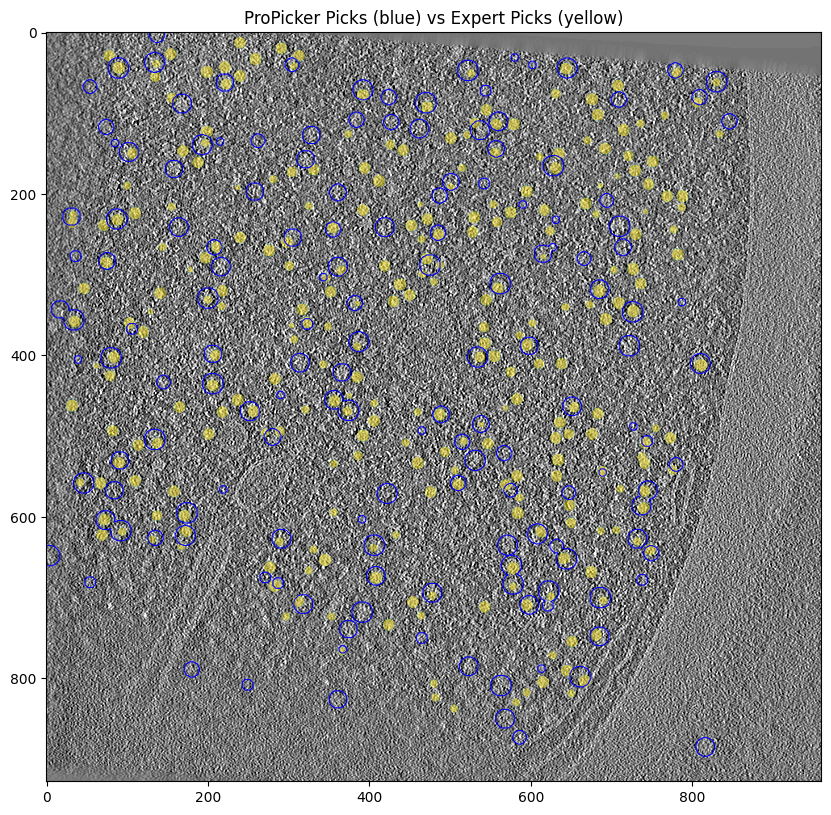

In [7]:
# draw the picked particles as balls
picks = draw_balls(
    positions=cluster_centroids_filt,
    shape=tomo.shape,
    radius=diameter//2,
    device=device,
)

# expert picks contained in the dataset
expert_picks = load_mrc_data(f"{EMPIAR10988_BASE_DIR}/labels/{ts_id}_cyto_ribosomes.mrc")[slice_of_interest].bool()


fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_title("ProPicker Picks (blue) vs Expert Picks (yellow)")
ax.imshow(tomo[100], vmin=-2*tomo.std(), vmax=2*tomo.std(), cmap="gray")
ax.contour(picks[100].cpu(), colors="blue", levels=[0.5], linewidths=0.75)
ax.imshow(tomo[100], vmin=-2*tomo.std(), vmax=2*tomo.std(), cmap="gray")
ax.imshow(expert_picks[100], alpha=0.5*expert_picks[100])

### Part 1, Step 3: Metric-based evaluation of picking performance

Computing picking metrics like the F1 score or Precision requires a true-positive criterion.
We use the same one as the authors of TomoTwin, that is, a pick is considered a true positive if a bounding box around is has an intersection-over-union (IoU) of at least 0.6 with a bounding box around and expert pick. 
The bounding box size should be chosen according to the particle size. For the ribosomes, we use a bounding box of 27x27x27 voxels. This true-positive criterion (which we used throughout our paper for consistency) is much stricter than the one used in the [DeePiCt paper](https://www.nature.com/articles/s41592-022-01746-2), in which the the EMPIAR-10988 dataset was proposed, so we get lower F1 scores.

In [8]:
bbox_size = 27  
coords["height"] = coords["width"] = coords["depth"] = bbox_size
cluster_centroids_filt["height"] = cluster_centroids_filt["width"] = cluster_centroids_filt["depth"] = bbox_size

In [9]:
# add class information to the picks so they can be matched with the corresponding expert picks
cluster_centroids_filt["class"] = "cyto_ribosome"

evaluate_picks(
    pred_positions=cluster_centroids_filt,
    gt_positions=coords,
    iou_thresh=0.6,  # a prediction is considered a true positive if the IoU is above this threshold
)

{'cyto_ribosome': {'F1': 0.2724358974358974,
  'Recall': 0.18325547969816744,
  'Precision': 0.5306971904266389,
  'TruePositiveRate': 0.18325547969816744,
  'TP': 510,
  'FP': 451,
  'FN': 2273}}

### Part 1, Step 3: Grid search for hyperparameter tuning

In the paper, we performed a grid search over the hyperparameters for cluster-based picking to find good values for `binarization_threshold`, `min_cluster_size` and `max_cluster_size`.

In [10]:
calibrated_results = get_best_case_cluster_based_picking_performance(
    pred_locmap_dict=pred_locmap_dict,
    optimize_thresh=True, # whether to optimize the binarization threshold
    n_thresh_steps=10,  # how many binarization thresholds to try between 0 and the max value in the locmap
    n_size_steps=5,  # how many min and max cluster sizes to try for each binarization threshold
    gt_positions=coords,
    metric="F1",  # you can optimize for "F1", "Precision" or "Recall"
    num_workers=0,
    # a predicted coordinate is a true positive if the IoU between a bbox-sized cube around it with any bbox-sized cube around a ground truth position is above this threshold 
    iou_thresh=0.6,  # 0.6 is pretty strict
)["cyto_ribosome"]
print(f"F1: {calibrated_results['F1']:.4f}, Precision: {calibrated_results['Precision']:.4f}, Recall: {calibrated_results['Recall']:.4f}")       

Running evaluation with 1 workers
Optimizing threshold for cyto_ribosome between 3.5694539771841116e-12 and 0.9796692728996277


cyto_ribosome (Best F1: 0.30): 100%|██████████| 250/250 [04:26<00:00,  1.07s/it]

F1: 0.3017, Precision: 0.5250, Recall: 0.2116


## Part 1, Step: 4 (Optional): Re-do for different prompts

In our paper, we found that ProPicker's performance can vary depending on the chosen prompt. Therefore, we typically repeated Steps 1-3 for multiple prompts per particle type and selected the best-performing prompt for picking in other tomograms.

# Part 2: Applying the Calibrated ProPicker to Multiple Tomograms

Now that we have found good values for the binarization and size thresholds for cluster-based picking on the calibration tomogram, we can apply ProPicker with the same prompt and hyperparameters to the remaining tomograms in the dataset.

In [11]:
# we use these hyperparameters for picking in other tomograms
calibrated_binarization_thresh = calibrated_results["thresh"]
calibrated_min_size = calibrated_results["min_size"]
calibrated_max_size = calibrated_results["max_size"]

In [12]:
# we used these 8 tomograms for evaluation in the paper
all_ts_ids = ["TS_026", "TS_027", "TS_028", "TS_034", "TS_037", "TS_041", "TS_043", "TS_045"]

all_f1s, all_precisions, all_recalls = [], [], []
for ts_id in all_ts_ids:
    # load tomo and annotations
    tomo_file = f"{EMPIAR10988_BASE_DIR}/tomograms/{ts_id}.rec"
    ribo_coord_file = f"{EMPIAR10988_BASE_DIR}/particle_lists/{ts_id}_cyto_ribosomes.csv"
    slice_of_interest = empiar10988_ts_to_slice_of_interest[ts_id]
    tomo = -1 * load_mrc_data(tomo_file).float()
    tomo = tomo[slice_of_interest].clone()
    coords = read_empiar10988_coords(ribo_coord_file)
    coords.Z -= slice_of_interest.start
    print(f"Tomo {ts_id}, Shape: {tomo.shape}, Number of Annotated Ribosomes: {len(coords)}")
    # inference
    pred_locmap_dict = get_pred_locmap_dict(
        model, 
        tomo, 
        prompt_subtomos_dict=prompt_subtomos_dict,  # use the same prompt as before 
        tomotwin_model_file=TOMOTWIN_MODEL_FILE,
        subtomo_size=64,
        subtomo_overlap=32,
        batch_size=16,
        mean_pool_locmaps=0,
    )
    # getting picks via clustering and filtering using calibrated hyperparameters
    binary_locmap = pred_locmap_dict["cyto_ribosome"] > calibrated_binarization_thresh
    cluster_centroids = get_cluster_centroids_df(binary_locmap)
    cluster_centroids_filt = cluster_centroids[
        (calibrated_min_size <= cluster_centroids["size"]) & (cluster_centroids["size"] <= calibrated_max_size)
    ].copy()
    # evaluate picks
    cluster_centroids_filt["height"] = cluster_centroids_filt["width"] = cluster_centroids_filt["depth"] = bbox_size
    coords["height"] = coords["width"] = coords["depth"] = bbox_size
    cluster_centroids_filt["class"] = "cyto_ribosome"
    results = evaluate_picks(
        pred_positions=cluster_centroids_filt,
        gt_positions=coords,
        iou_thresh=0.6,
    )["cyto_ribosome"]
    print(f"F1: {results['F1']:.2f}, Precision: {results['Precision']:.2f}, Recall: {results['Recall']:.2f}")
    all_f1s.append(results["F1"])
    all_precisions.append(results["Precision"])
    all_recalls.append(results["Recall"])

Tomo TS_026, Shape: torch.Size([167, 928, 960]), Number of Annotated Ribosomes: 838


/opt/conda/envs/ppicker/lib/python3.11/site-packages/propicker/inference/tomotwin.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weightspth, ma

F1: 0.24, Precision: 0.29, Recall: 0.20
Tomo TS_027, Shape: torch.Size([200, 928, 960]), Number of Annotated Ribosomes: 1673


/opt/conda/envs/ppicker/lib/python3.11/site-packages/propicker/inference/tomotwin.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weightspth, ma

F1: 0.29, Precision: 0.47, Recall: 0.21
Tomo TS_028, Shape: torch.Size([315, 928, 960]), Number of Annotated Ribosomes: 5305


...

F1: 0.22, Precision: 0.49, Recall: 0.14
Tomo TS_043, Shape: torch.Size([153, 928, 960]), Number of Annotated Ribosomes: 1815


/opt/conda/envs/ppicker/lib/python3.11/site-packages/propicker/inference/tomotwin.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weightspth, ma

F1: 0.26, Precision: 0.40, Recall: 0.19
Tomo TS_045, Shape: torch.Size([304, 928, 960]), Number of Annotated Ribosomes: 2348


/opt/conda/envs/ppicker/lib/python3.11/site-packages/propicker/inference/tomotwin.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(weightspth, ma

F1: 0.16, Precision: 0.39, Recall: 0.10


The mean F1, Precision, and Recall across all tomograms should be close to the numbers we for prompt-based picking with ProPicker-C in Figure 6 and Figure H.1 in our paper:

In [13]:
print(f"Mean F1: {np.mean(all_f1s):.2f} ± {np.std(all_f1s):.2f}")
print(f"Mean Precision: {np.mean(all_precisions):.2f} ± {np.std(all_precisions):.2f}")
print(f"Mean Recall: {np.mean(all_recalls):.2f} ± {np.std(all_recalls):.2f}")

Mean F1: 0.22 ± 0.05
Mean Precision: 0.42 ± 0.07
Mean Recall: 0.16 ± 0.04


# Conclusion

Prompt-based picking with ProPicker out-of-the-box gives decent results for picking ribosomes in the EMPIAR-10988 dataset.

For best performance with ProPicker, we recommend fine-tuning the model on labeled data, which the out-of-the-box ProPicker can help you produce. A tutorial on fine-tuning can be found in the second tutorial notebook.